### Name: Riya Shyam Huddar(MDS202431)
### Name: Shruti Sharma (MDS202435)

### AML Assignment 3 (Continuous)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import copy
import random
import collections
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [ ]:
!apt-get install -y swig
!pip install "gymnasium[box2d]"


## Continuous Lunar Lander: Environment Setup

The environment below creates the continuous-action version of LunarLander.  
It uses an 8-dimensional continuous state space and a 2-dimensional continuous action space.

Key points:
- `continuous=True` enables continuous engine controls.
- Custom physics parameters (gravity, wind, turbulence) are set.


In [ ]:
env = gym.make(
    "LunarLander-v3",
    continuous=True,
    gravity=-10.0,
    enable_wind=False,
    wind_power=15.0,
    turbulence_power=1.5,
    render_mode="rgb_array"
)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)


Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Box(-1.0, 1.0, (2,), float32)


## Running a Random Policy

This part runs sample episodes using completely random continuous actions.  
The goal is simply to understand how the environment behaves by observing:

- How long random episodes typically last.  
- What the reward range looks like when no learning is happening.  
- How the lander reacts to arbitrary continuous engine inputs.  

This serves as a baseline before applying any learning method.


In [ ]:
def run_random_episode(env):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    t = 0

    while not done:
        action = env.action_space.sample()   # random continuous action
        obs, reward, term, trunc, info = env.step(action)
        done = term or trunc

        total_reward += reward
        t += 1

    print(f"Episode finished in {t} steps with reward {total_reward:.2f}")
    return total_reward

# Run a few episodes
for i in range(5):
    run_random_episode(env)


Episode finished in 112 steps with reward -249.20
Episode finished in 72 steps with reward -84.59
Episode finished in 109 steps with reward -216.46
Episode finished in 167 steps with reward -183.82
Episode finished in 86 steps with reward -309.38


## Recording a Random Policy Rollout

This section records a sample episode using random continuous actions.  
This helps visualize how uncontrolled actions cause unstable flight and hard crashes.

Baseline random-policy results (example):
- Episodes: ~70–170 steps  
- Rewards: typically large negative values (–80 to –300)  

These runs act as a reference point before applying MC or TD learning.


In [ ]:
from gymnasium.wrappers import RecordVideo

def record_random(env):
    rec = RecordVideo(env, video_folder="videos_random", name_prefix="random_lander")
    obs, _ = rec.reset()
    done = False

    while not done:
        action = env.action_space.sample()      # random action
        obs, r, term, trunc, _ = rec.step(action)
        done = term or trunc

        # Force render to actually capture the frame
        frame = rec.render()
        assert frame is not None  # makes sure we get a frame

    rec.close()
    print("Random agent rollout saved!")


In [ ]:
record_random(env)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Random agent rollout saved!



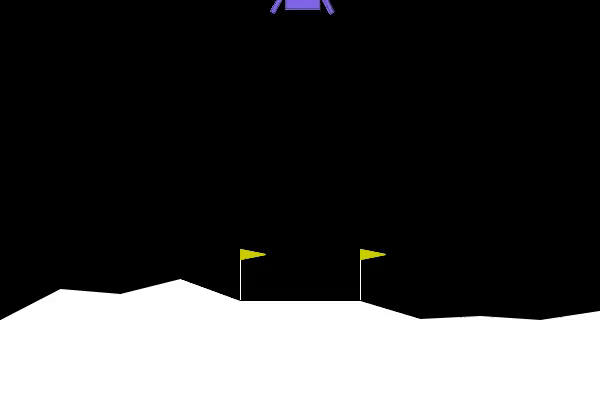

In [197]:
import base64
from IPython.display import HTML

gif_path = "videos_random/random_lander_demo.gif"

with open(gif_path, "rb") as f:
    gif_data = f.read()

gif_base64 = base64.b64encode(gif_data).decode("utf-8")

HTML(f'<img src="data:image/gif;base64,{gif_base64}" width="480">')


## Continuous Lunar Lander: Using DDPG

The continuous-action version of Lunar Lander cannot be solved directly using tabular TD methods or DQN, because they handle **discrete actions** only.  
To address this, we use **Deep Deterministic Policy Gradient (DDPG)**, which applies the same **TD learning principles** as DQN, but for continuous action spaces.

### Key Points

- **TD-Based Learning:** The critic network in DDPG is updated using a TD target:  
  > target = r + γ · Q_target(s′, μ_target(s′))  
  This is analogous to the TD(0) updates in DQN.

- **Actor Network:** An additional network outputs continuous actions, replacing the discrete action selection in DQN.

- **Replay Buffer & Target Networks:** Like DQN, DDPG uses a replay buffer and target networks for stable learning.  

- **Off-Policy Learning:**  
  - DDPG is **off-policy** because the agent learns from transitions stored in the replay buffer, which may come from **older policies** or random exploration.  
  - This allows efficient reuse of past experiences and stabilizes learning, especially with continuous actions where exploring the full action space is expensive.

- **Continuous Control:** The actor allows the agent to select real-valued engine thrusts, which is required for this version of the environment.


## DDPG Hyperparameters and Setup

This block configures the DDPG agent for the continuous Lunar Lander environment.

**Core Hyperparameters**
- **Batch size:** 256  
- **Discount factor (γ):** 0.99  
- **Learning rates:**  
  - Actor: **1e-4**  
  - Critic: **5e-4**  
- **Replay buffer size:** 1,000,000 transitions (supports stable off-policy learning)  
- **Soft update rate (`τ`):** 0.0025 (smaller → smoother target updates)

**Exploration Noise**
- **Initial noise σ:** 0.25  
- **Minimum noise σ:** 0.05  
- **Decay rate:** 0.9998 per step  
This encourages early exploration while gradually shifting toward stability.

**Training Setup**
- **Minimum replay size:** 10,000 samples before training begins (prevents unstable early updates)



In [166]:
# DDPG Hyperparameters
DDPG_BATCH_SIZE      = 256       # batch size
DDPG_GAMMA           = 0.99      # Discount factor
ACTOR_LR             = 1e-4      # Actor learning rate
CRITIC_LR            = 5e-4      # Critic learning rate
DDPG_REPLAY_CAPACITY = 1000000   # buffer for stable off-policy learning
DDPG_TAU             = 0.0025    # Smaller tau for slower, smoother target updates
NOISE_SIGMA_START    = 0.25      # Start with slightly higher exploration noise
NOISE_SIGMA_MIN      = 0.05      # Minimum noise
NOISE_DECAY          = 0.9998    # decay to maintain exploration

# Setup Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIN_REPLAY_SIZE = 10000          # Minimum number of samples before training begins


## Actor, Critic, and Replay Buffer

This block defines the main components of the DDPG agent:

- **Actor Network:**  
  - Inputs the state and outputs a continuous action.  
  - Uses two hidden layers with ReLU activations.  
  - Output is bounded with `tanh` and scaled by `max_action` to match environment limits.  

- **Critic Network:**  
  - Inputs the state and action together and outputs a single Q-value.  
  - Two hidden layers with ReLU.  
  - Trains using TD updates to evaluate action quality.

- **Replay Buffer:**  
  - Stores past transitions `(state, action, reward, next_state, done)` up to a fixed capacity.  
  - Samples random batches for training to stabilize learning and break correlations in sequential data.


In [167]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action, fc1_dims=256, fc2_dims=256):
        super(Actor, self).__init__()
        self.l1 = nn.Linear(state_dim, fc1_dims)
        self.l2 = nn.Linear(fc1_dims, fc2_dims)
        self.l3 = nn.Linear(fc2_dims, action_dim)
        self.max_action = max_action

        # Initialize final layer weights to be small for stability
        self.l3.weight.data.uniform_(-3e-3, 3e-3)
        self.l3.bias.data.uniform_(-3e-3, 3e-3)

    def forward(self, state):
        a = F.relu(self.l1(state))
        a = F.relu(self.l2(a))
        # Use tanh to bound output to [-1, 1], then scale by max_action
        return self.max_action * torch.tanh(self.l3(a))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, fc1_dims=256, fc2_dims=256):
        super(Critic, self).__init__()
        # Input is concatenated state and action
        self.l1 = nn.Linear(state_dim + action_dim, fc1_dims)
        self.l2 = nn.Linear(fc1_dims, fc2_dims)
        self.l3 = nn.Linear(fc2_dims, 1) # Output a single Q-value

    def forward(self, state, action):
        # Concatenate state and action along dimension 1
        q = torch.cat([state, action], 1)
        q = F.relu(self.l1(q))
        q = F.relu(self.l2(q))
        return self.l3(q)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)

        # Convert list of tuples into numpy arrays
        states, actions, rewards, next_states, dones = zip(*transitions)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.float32),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

## DDPG Agent Class

This class implements the DDPG agent, which wraps the actor, critic, and training routines.

- **Initialization:**  
  - Creates actor and critic networks along with their target networks.  
  - Sets optimizers and replay buffer.  
  - Tracks exploration noise for action selection.

- **Action Selection (`act`)**:  
  - Returns actions from the actor network.  
  - Optional Gaussian noise added for exploration.  
  - Actions are clipped to valid environment range.

- **Replay Buffer Interaction:**  
  - `store_transition` saves experiences `(state, action, reward, next_state, done)` for off-policy learning.

- **Soft Updates (`soft_update`)**:  
  - Gradually updates target networks using `tau` to stabilize learning.

- **Training Step (`train_step`)**:  
  - Samples a batch from the replay buffer.  
  - **Critic update:** TD target using target networks.  
  - **Actor update:** maximize Q-values predicted by the critic.  
  - Soft updates applied to both actor and critic targets.  
  - Gradient clipping ensures stable training.




In [168]:
class DDPGAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        max_action,
        gamma=DDPG_GAMMA,
        actor_lr=ACTOR_LR,
        critic_lr=CRITIC_LR,
        batch_size=DDPG_BATCH_SIZE,
        buffer_size=DDPG_REPLAY_CAPACITY,
        tau=DDPG_TAU
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.max_action = max_action
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.device = DEVICE
        self.current_sigma = NOISE_SIGMA_START # Used for Gaussian noise

        # 1. Initialize Actor
        self.actor = Actor(state_dim, action_dim, max_action).to(self.device)
        self.actor_target = copy.deepcopy(self.actor)
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)

        # 2. Initialize Critic
        self.critic = Critic(state_dim, action_dim).to(self.device)
        self.critic_target = copy.deepcopy(self.critic)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

        # 3. Replay Buffer
        self.replay_buffer = ReplayBuffer(buffer_size)

    def act(self, state, add_noise=True):
        """Select action with optional Gaussian noise for exploration."""
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_t).cpu().data.numpy().flatten()
        self.actor.train()

        if add_noise:
            # Add simple Gaussian noise (Exploration)
            action += np.random.normal(0, self.current_sigma, size=self.action_dim)

        return np.clip(action, -self.max_action, self.max_action)

    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def soft_update(self, local_model, target_model):
        """Soft update model parameters: target = tau*local + (1-tau)*target"""
        for target_param, param in zip(target_model.parameters(), local_model.parameters()):
            target_param.data.copy_(self.tau * param.data + (1.0 - self.tau) * target_param.data)

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return None, None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)

        # Convert numpy arrays to PyTorch tensors
        state = torch.from_numpy(states).float().to(self.device)
        action = torch.from_numpy(actions).float().to(self.device)
        reward = torch.from_numpy(rewards).float().to(self.device).unsqueeze(1)
        next_state = torch.from_numpy(next_states).float().to(self.device)
        done = torch.from_numpy(dones).float().to(self.device).unsqueeze(1)

        # update critic
        with torch.no_grad():
            # Get next action from target actor: a_next = pi_target(s_next)
            next_action = self.actor_target(next_state)
            # Compute target Q-value: y_i = r + gamma * Q_target(s_next, a_next) * (1 - done)
            target_Q = reward + (self.gamma * (1 - done) * self.critic_target(next_state, next_action))

        # Get current Q estimate
        current_Q = self.critic(state, action)
        critic_loss = F.mse_loss(current_Q, target_Q)

        # Optimize Critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        # Apply gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_optimizer.step()

        # update actor
        # Compute Actor Loss: L_actor = -mean(Q(s, pi_local(s)))
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # Optimize Actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # update target networks
        self.soft_update(self.critic, self.critic_target)
        self.soft_update(self.actor, self.actor_target)

        return critic_loss.item(), actor_loss.item()

## Training Loop

This function trains the DDPG agent on the continuous Lunar Lander environment.

### Steps:

1. **Environment and Agent Setup:**  
   - Determines state and action dimensions.  
   - Initializes the `DDPGAgent` with actor, critic, and replay buffer.

2. **Start Phase:**  
   - Collects `MIN_REPLAY_SIZE` random transitions to populate the replay buffer.  
   - Ensures stable initial learning before using the agent’s policy.

3. **Episode Loop:**  
   For each episode:
   - **Action Selection:** Actor outputs an action with optional Gaussian noise for exploration.  
   - **Environment Step:** Agent interacts with the environment and receives reward.  
   - **Store and Learn:** Transition is stored in the replay buffer; agent performs a training step.  
   - **Decayed Gaussian Noise:**  
     - Noise starts large to encourage exploration of different actions.  
     - Gradually decays over episodes to allow the agent to exploit learned knowledge more reliably.  
     - Balances exploration and exploitation effectively.

4. **Logging and Evaluation:**  
   - Tracks episode return and moving average over the last 100 episodes.  
   - Prints periodic updates and marks the environment as solved if average score ≥ 200.  
   - Saves actor weights and returns when solved.

5. **Completion:**  
   - Saves final returns even if the environment is not fully solved.

### Summary:

- The critic uses **TD-based learning** to estimate Q-values.  
- The actor improves the policy by maximizing the critic’s predicted value.  
- Decaying noise helps the agent explore early and gradually focus on exploitation.


In [ ]:
def train_continuous_ddpg(env, num_episodes=1000, max_steps=1000):
    # Determine environment dimensions
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    agent = DDPGAgent(state_dim, action_dim, max_action)
    returns = []
    score_window = collections.deque(maxlen=100)
    current_sigma = NOISE_SIGMA_START # Start with high noise

    print(f"Collecting {MIN_REPLAY_SIZE} random transitions...")
    state, _ = env.reset(seed=42)

    # Warmup phase: collect random transitions
    while len(agent.replay_buffer) < MIN_REPLAY_SIZE:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.store_transition(state, action, reward, next_state, float(done))
        state = next_state
        if done: state, _ = env.reset()

    print("Starting DDPG training...")
    print("-" * 65)
    print("Episode | Steps | Total Score | Avg Score (100) | Noise Sigma | Status")
    print("-" * 65)

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        episode_return = 0
        t = 0

        # Update agent's sigma for the current episode
        agent.current_sigma = current_sigma

        for t in range(max_steps):
            # 1. Action Selection: Get action with Gaussian noise
            action = agent.act(state, add_noise=True)

            # 2. Environment Step
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # 3. Store and Learn
            agent.store_transition(state, action, reward, next_state, float(done))
            agent.train_step()

            # 4. Update State and Score
            state = next_state
            episode_return += reward

            if done:
                break

        # 5. Noise Decay (applied after episode completion)
        current_sigma = max(NOISE_SIGMA_MIN, current_sigma * NOISE_DECAY)

        # 6. Logging and Evaluation
        score_window.append(episode_return)
        returns.append(episode_return)
        avg_score = np.mean(score_window)

        log_status = ""

        if avg_score >= 200.0 and episode >= 100:
            log_status = "*** SOLVED! ***"

        if episode % 10 == 0 or avg_score >= 200.0:
            print(f"{episode:7d} | {t:5d} | {episode_return:11.2f} | {avg_score:15.2f} | {current_sigma:11.4f} | {log_status}")

        if avg_score >= 200.0 and episode >= 100:
            print("\n" + "=" * 65)
            print(f"*** Environment solved at episode {episode} ***")
            print(f"Final Average Score: {avg_score:.2f}")

            # --- SAVE Weights and Returns ---
            torch.save(agent.actor.state_dict(), 'ddpg_actor_solved.pth')
            np.save('ddpg_training_returns.npy', returns)
            print("Saved Actor weights to 'ddpg_actor_solved.pth'.")
            print("Saved training returns to 'ddpg_training_returns.npy'.")
            print("=" * 65)
            break

    env.close()

    # --- SAVE Final Returns (even if not solved) ---
    np.save('ddpg_training_returns.npy', returns)
    print("\nTraining finished.")
    print("Saved final training returns to 'ddpg_training_returns.npy'.")

    return returns, agent



In [169]:
ddpg_returns, ddpg_agent = train_continuous_ddpg(env=env, num_episodes=1000)

Starting DDPG training...
-----------------------------------------------------------------
Episode | Steps | Total Score | Avg Score (100) | Noise Sigma | Status
-----------------------------------------------------------------
     10 |   378 |     -106.85 |         -325.63 |      0.2495 | 
     20 |   999 |      -67.63 |         -226.22 |      0.2490 | 
     30 |   209 |      -87.00 |         -204.74 |      0.2485 | 
     40 |   999 |      -56.87 |         -182.37 |      0.2480 | 
     50 |   928 |     -111.05 |         -176.10 |      0.2475 | 
     60 |   999 |      -41.49 |         -147.99 |      0.2470 | 
     70 |   943 |      161.82 |         -118.21 |      0.2465 | 
     80 |   939 |     -248.16 |         -113.89 |      0.2460 | 
     90 |   426 |     -219.17 |         -107.21 |      0.2455 | 
    100 |   999 |       50.46 |          -94.79 |      0.2450 | 
    110 |   999 |      -51.15 |          -66.48 |      0.2446 | 
    120 |   999 |      -24.71 |          -57.09 |      0

## DDPG Training Results and Evaluation

After training the DDPG agent, we saved the **actor network** and the **training returns**.  
We can now visualize the learning progress and evaluate the policy on a set of test episodes.

### Training Curve
The plot below shows the **episode returns over training**, along with a running average over the last 100 episodes to illustrate performance improvement and convergence.


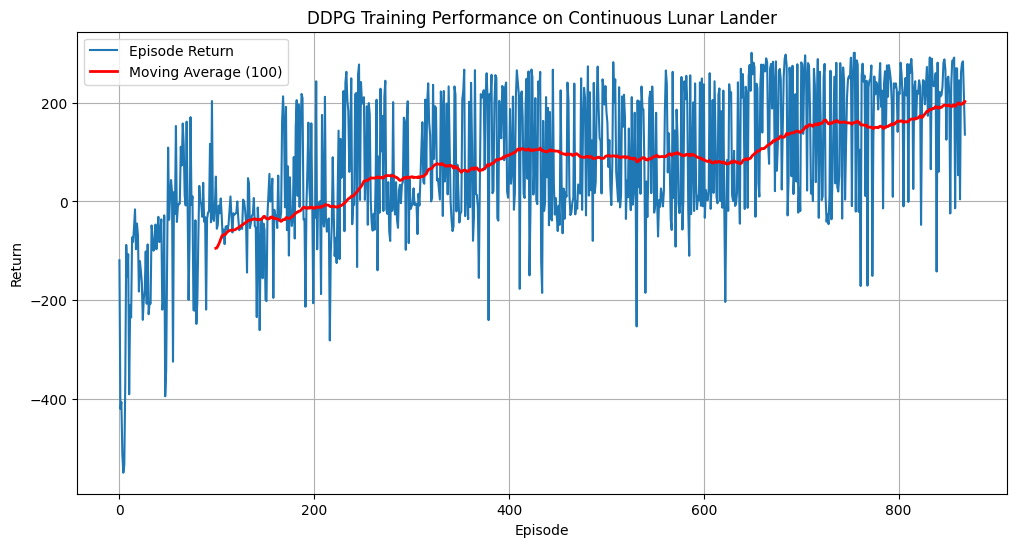

In [192]:
# Load training returns
returns = np.load('ddpg_training_returns.npy')

# Compute moving average (window=100)
window = 100
moving_avg = np.convolve(returns, np.ones(window)/window, mode='valid')

# Plot
plt.figure(figsize=(12,6))
plt.plot(returns, label='Episode Return')
plt.plot(np.arange(window-1, len(returns)), moving_avg, label='Moving Average (100)', color='red', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DDPG Training Performance on Continuous Lunar Lander')
plt.legend()
plt.grid(True)
plt.show()


### Policy Evaluation

We evaluate the trained actor over **30 test episodes** without exploration noise (deterministic actions) to demonstrate the learned policy performance.


In [188]:
# Load environment and trained actor
env = gym.make("LunarLander-v3", continuous=True, render_mode="rgb_array")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# Initialize agent and load actor weights
agent = DDPGAgent(state_dim, action_dim, max_action)
agent.actor.load_state_dict(torch.load('ddpg_actor_solved.pth', map_location=agent.device))
agent.actor.eval()

# Evaluate
num_test_episodes = 30
test_returns = []

print("Episode-wise Returns:")
for ep in range(1, num_test_episodes + 1):
    state, _ = env.reset()
    done = False
    ep_return = 0
    while not done:
        action = agent.act(state, add_noise=False)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        ep_return += reward
    test_returns.append(ep_return)
    print(f"Episode {ep:2d}: Return = {ep_return:.2f}")

# Compute statistics
avg_return = np.mean(test_returns)
std_return = np.std(test_returns)

print("\nSummary Statistics:")
print(f"Average Return: {avg_return:.2f}")
print(f"Standard Deviation: {std_return:.2f}")


Episode-wise Returns:
Episode  1: Return = 246.66
Episode  2: Return = 296.28
Episode  3: Return = 218.41
Episode  4: Return = 271.89
Episode  5: Return = 243.42
Episode  6: Return = 293.78
Episode  7: Return = 279.66
Episode  8: Return = 259.70
Episode  9: Return = 256.01
Episode 10: Return = 292.09
Episode 11: Return = 307.92
Episode 12: Return = 255.05
Episode 13: Return = 238.86
Episode 14: Return = 265.23
Episode 15: Return = 220.41
Episode 16: Return = 255.92
Episode 17: Return = 238.14
Episode 18: Return = 239.55
Episode 19: Return = 266.75
Episode 20: Return = 268.88
Episode 21: Return = 250.52
Episode 22: Return = 279.23
Episode 23: Return = 273.56
Episode 24: Return = 233.84
Episode 25: Return = 241.88
Episode 26: Return = 272.29
Episode 27: Return = 289.92
Episode 28: Return = 242.73
Episode 29: Return = 273.72
Episode 30: Return = 282.20

Summary Statistics:
Average Return: 261.82
Standard Deviation: 22.51


In [185]:
from gymnasium.wrappers import RecordVideo

# Wrap the environment to save a video
video_env = RecordVideo(env, video_folder="ddpg_test_videos", name_prefix="ddpg_lander_demo")

state, _ = video_env.reset()
done = False
ep_return = 0

while not done:
    action = agent.act(state, add_noise=False)  # deterministic action
    next_state, reward, terminated, truncated, _ = video_env.step(action)
    done = terminated or truncated
    state = next_state
    ep_return += reward

video_env.close()
print(f"Demo rollout finished with return: {ep_return:.2f}")
print("Video saved in 'ddpg_test_videos/' folder.")


Demo rollout finished with return: 303.53
Video saved in 'ddpg_test_videos/' folder.



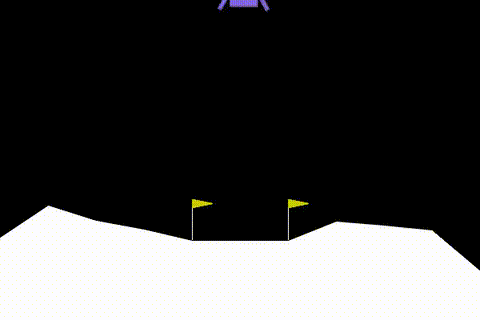

In [195]:
import base64

gif_path = "ddpg_test_videos/ddpg_lander_demo.gif"

with open(gif_path, "rb") as f:
    gif_data = f.read()

gif_base64 = base64.b64encode(gif_data).decode("utf-8")

from IPython.display import HTML
HTML(f'<img src="data:image/gif;base64,{gif_base64}" width="480">')


100%|██████████| 1000/1000 [01:57<00:00,  8.48it/s]


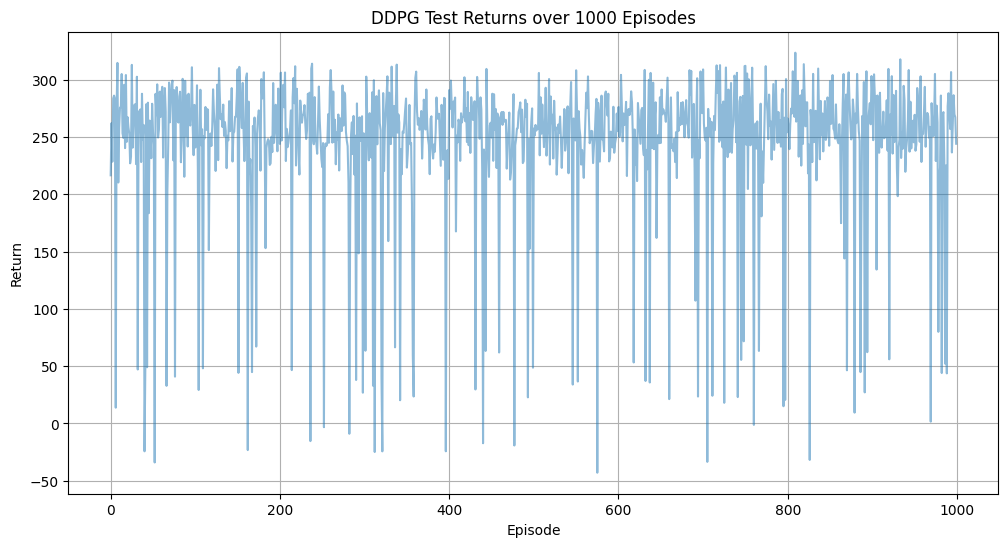

Average Return: 245.80
Standard Deviation: 64.87
Max Return: 323.56
Min Return: -42.96


In [191]:
from tqdm import trange

# Load environment and trained actor
env = gym.make("LunarLander-v3", continuous=True)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

# Initialize agent and load actor weights
agent = DDPGAgent(state_dim, action_dim, max_action)
agent.actor.load_state_dict(torch.load('ddpg_actor_solved.pth', map_location=agent.device))
agent.actor.eval()

# Evaluate over many episodes
num_test_episodes = 1000
test_returns = []

for _ in trange(num_test_episodes):
    state, _ = env.reset()
    done = False
    ep_return = 0
    while not done:
        action = agent.act(state, add_noise=False)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        ep_return += reward
    test_returns.append(ep_return)

# Plotting
plt.figure(figsize=(12,6))
plt.plot(test_returns, alpha=0.5)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title(f"DDPG Test Returns over {num_test_episodes} Episodes")
plt.grid(True)
plt.show()

# Print summary statistics
avg_return = np.mean(test_returns)
std_return = np.std(test_returns)
print(f"Average Return: {avg_return:.2f}")
print(f"Standard Deviation: {std_return:.2f}")
print(f"Max Return: {np.max(test_returns):.2f}")
print(f"Min Return: {np.min(test_returns):.2f}")
